# Getting the ACF for a design PSD

Compute the autocovariance function (ACF) corresponding to the LIGO-Virgo design noise power spectrum (PSD).

In [13]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal as ssig
import lalsimulation as lalsim

sns.set(context='notebook', palette='colorblind')

## Getting PSD arrays

We need to first get PSDs. To do this, we will take advantage of the reference PSDs shipped with _LALSimulation_. The choices below correspond to the design sensitivies of advanced LIGO Hanford (`H1`), LIGO Livingston (`L1`) and Virgo (`V1`). Since these are projected sensitivies, these are the same for H and L, but in a real analysis that would not be the case (because, although the detectors have the same design, in real life they are independent).

Of course, the _LALSimulation_ functions could be replaced with whatever PSD you want.

In [3]:
psd_func_dict = {
    'H1': lalsim.SimNoisePSDaLIGOZeroDetHighPower,
    # 'L1': lalsim.SimNoisePSDaLIGOZeroDetHighPower,
    'V1': lalsim.SimNoisePSDAdvVirgo,
}
ifos = list(psd_func_dict.keys())

Now we want to instantiate the PSDs, to get an array of values instead of a function. To do this, we need an array of frequencies corresponding to the time series data we constructed above. **NOTE:** all this does is evaluate the PSDs at the desired frequencies---you could skip straight to this part if you had an array in the first place.

In [8]:
# define sampling rate and duration
fsamp = 8192
duration = 2

delta_t = 1/fsamp
tlen = int(round(duration / delta_t))

# define minimum frequency, below which the PSD will taper
fmin = 10

In [9]:
freqs = fft.rfftfreq(tlen, delta_t)
delta_f = freqs[1] - freqs[0]

# we will want to pad low frequencies; the function below applies a
# prescription to do so smoothly, but this is not really needed: you
# could just set all values below `fmin` to a constant.
def pad_low_freqs(f, psd_ref):
    return psd_ref + psd_ref*(fmin-f)*np.exp(-(fmin-f))/3

psd_dict = {}
for ifo in ifos:
    psd = np.zeros(len(freqs))
    for i,f in enumerate(freqs):
        if f >= fmin:
            psd[i] = psd_func_dict[ifo](f)
        else:
            psd[i] = pad_low_freqs(f, psd_func_dict[ifo](fmin))
    psd_dict[ifo] = psd

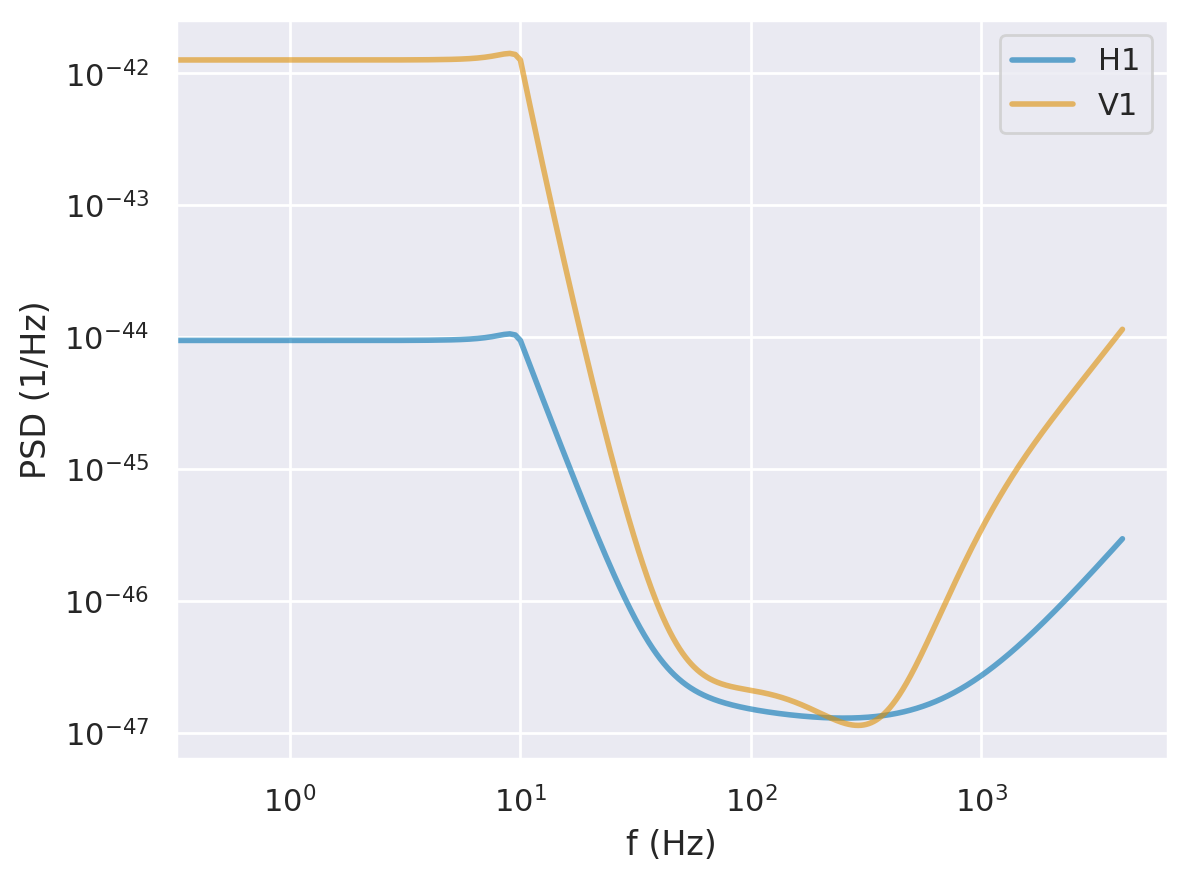

In [12]:
for ifo, psd in psd_dict.items():
    plt.loglog(freqs, psd, label=ifo, alpha=0.6, lw=2)
plt.xlabel('f (Hz)')
plt.ylabel('PSD (1/Hz)')
plt.legend();

## Computing ACFs

We can now turn the above PSDs into ACFs, for a given (truncated) analysis length.

In [11]:
acf_dict = {}
for ifo, psd in psd_dict.items():
    acf_dict[ifo] = 0.5*np.fft.irfft(psd) / delta_t

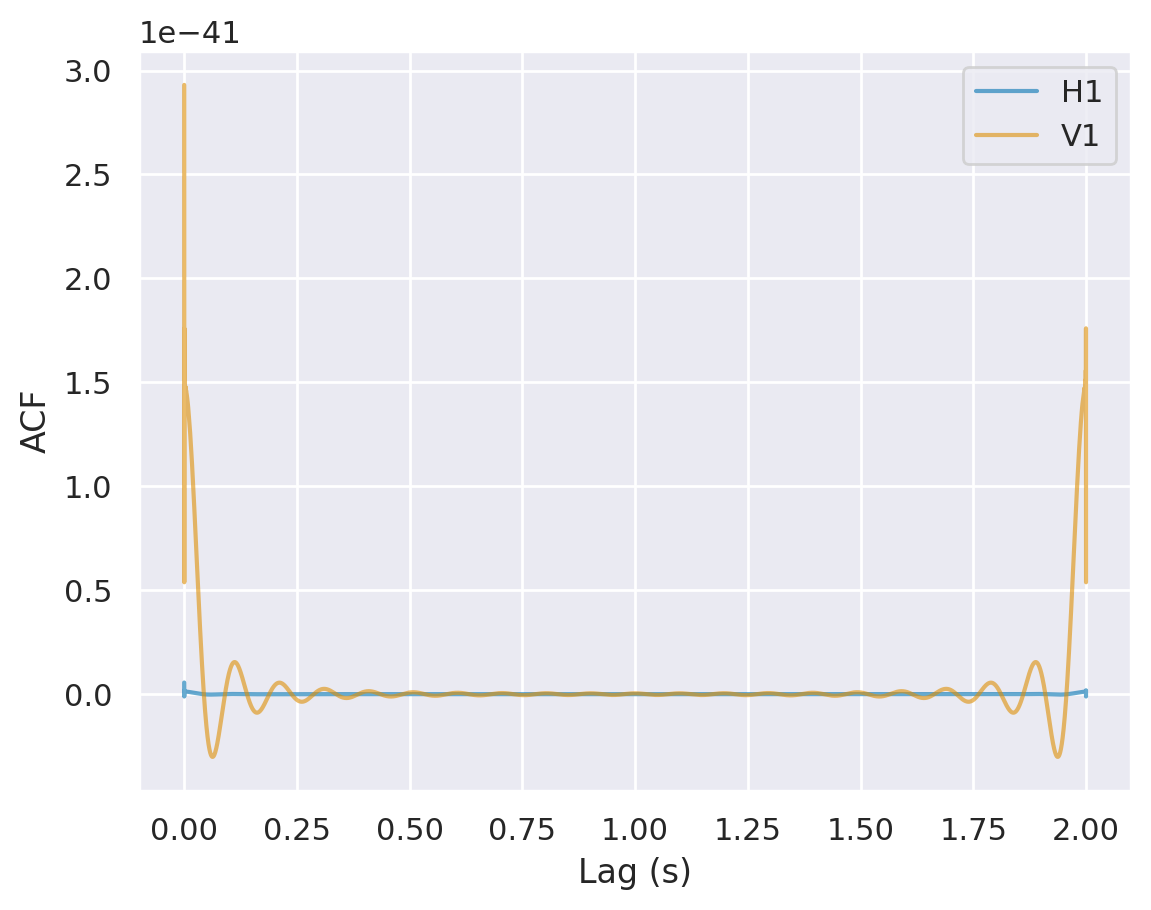

In [18]:
for ifo, acf in acf_dict.items():
    plt.plot(delta_t*np.arange(len(acf)), acf, label=ifo, alpha=0.6)
plt.xlabel('Lag (s)')
plt.ylabel('ACF')
plt.legend();

### Test ACF

Let's make sure that we can get a positive-definite covariance for this ACF.

In [24]:
import scipy.linalg as sl

In [26]:
# covariance length in seconds
analysis_duration = 0.5
analysis_length = int(0.5/delta_t)

for ifo, acf in acf_dict.items():
    np.linalg.cholesky(sl.toeplitz(acf[:analysis_length]))

print("No errors!")

No errors!
